In [244]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('../files/train.csv')
test_df = pd.read_csv('../files/test.csv')

In [263]:
# columns
print(train_df.columns.values)
print(test_df.columns.values)

['Survived' 'Pclass' 'Age' 'Fare' 'Sex' 'Embarked_C' 'Embarked_Q'
 'Embarked_S' 'isAlone']
['PassengerId' 'Pclass' 'Age' 'Fare' 'Sex' 'Embarked_C' 'Embarked_Q'
 'Embarked_S' 'isAlone']


In [246]:
# dimension
print(train_df.shape)
print(test_df.shape)

(891, 12)
(418, 11)


In [247]:
# check if dataset contains missing data

print("Train df\n", train_df.isna().sum())
print("\nTest df\n", test_df.isna().sum())

Train df
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Test df
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [248]:
print(train_df.info())
print("\n")
print(test_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   P

In [249]:
# Identify the unique values of the categorical features (Sex, Embarked)
print(train_df['Sex'].unique())
print(train_df['Embarked'].unique())

['male' 'female']
['S' 'C' 'Q' nan]


In [250]:
# Get the main statistics of numerical features
# analisar estes dados tipo media de survived
print(train_df.describe())
print(train_df.describe(include=['O']))

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
                           Name   Sex  Ticket    Cabin Embarked
count            

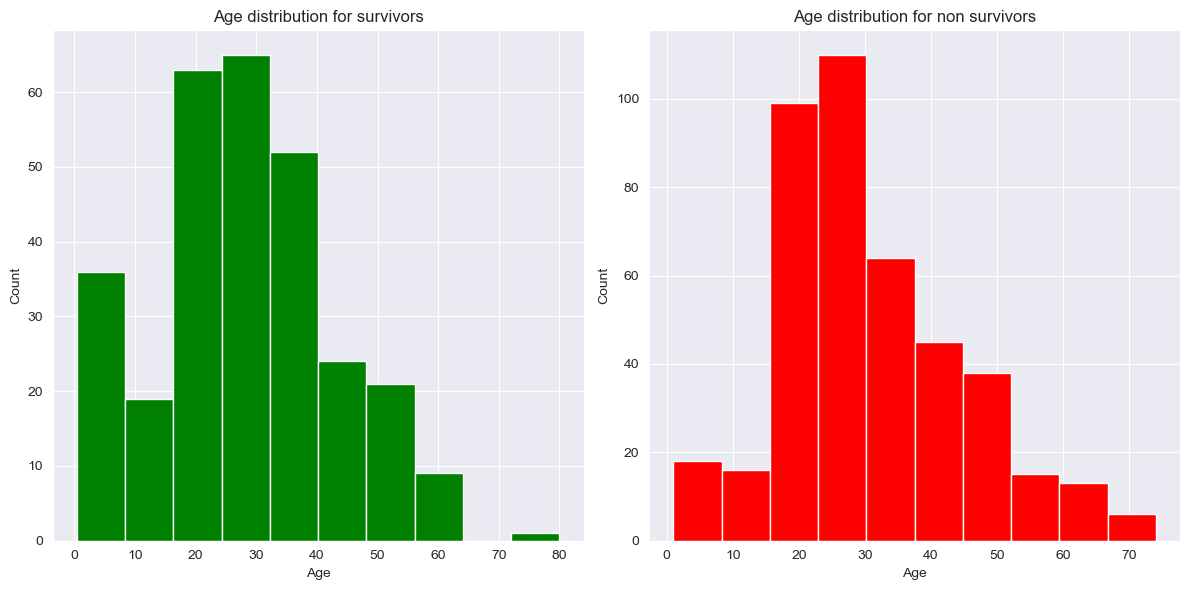

Mean age of survivors:
 Age    28.34369
dtype: float64
Mean age of non survivors:
 Age    30.626179
dtype: float64


In [251]:
# survivors and non survivors by age
survived_df = train_df[train_df['Survived'] == 1][['Age']]
not_survived_df = train_df[train_df['Survived'] == 0][['Age']]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(survived_df['Age'].dropna(), color='green')
plt.title('Age distribution for survivors')
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(not_survived_df['Age'].dropna(), color='red')
plt.title('Age distribution for non survivors')
plt.xlabel('Age')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

print('Mean age of survivors:\n', survived_df.mean())
print('Mean age of non survivors:\n', not_survived_df.mean())
# Most passengers are in 15-35 age range.
# Children had high survival rate

        Survived
Sex             
female  0.742038
male    0.188908


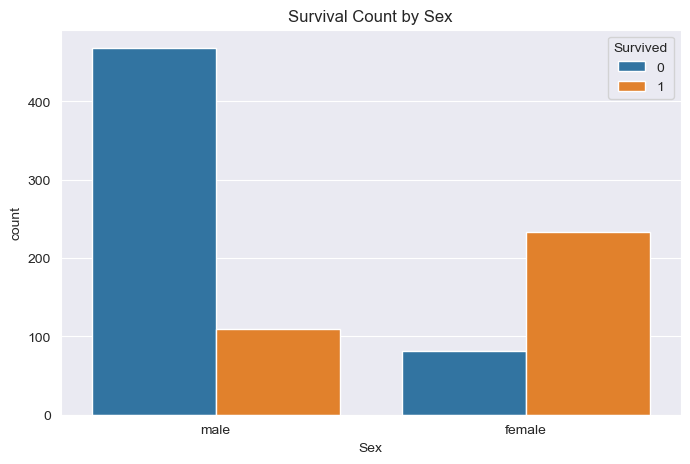

        Survived
Pclass          
1       0.629630
2       0.472826
3       0.242363


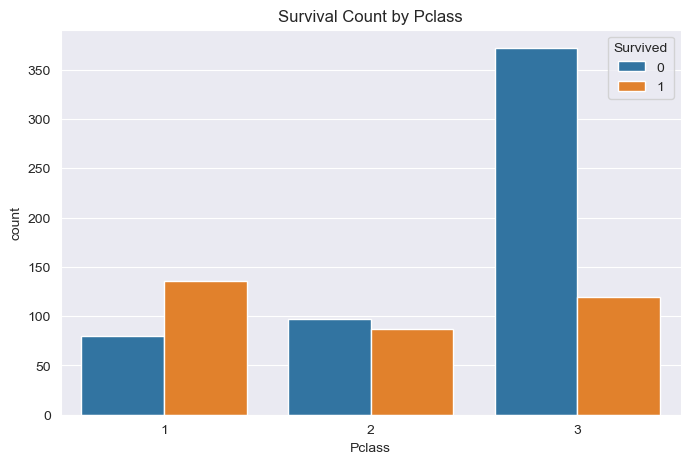

          Survived
Embarked          
C         0.553571
Q         0.389610
S         0.336957


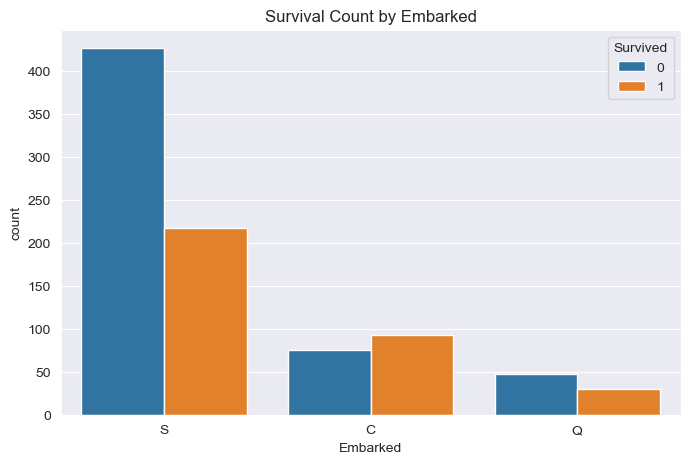

In [252]:
# plot each categorical feature and calculate survival rate
categorical_features = ['Sex', 'Pclass', 'Embarked']

for feature in categorical_features:
    print(train_df[[feature, 'Survived']].groupby([feature]).mean())

    plt.figure(figsize=(8, 5))
    sns.countplot(x=feature, hue='Survived', data=train_df)
    plt.title('Survival Count by ' + feature)
    plt.show()

# Female passengers had much better survival rate than males.
# Most passengers in Pclass=1 survived
# Port of embarkation may correlate with survival rate

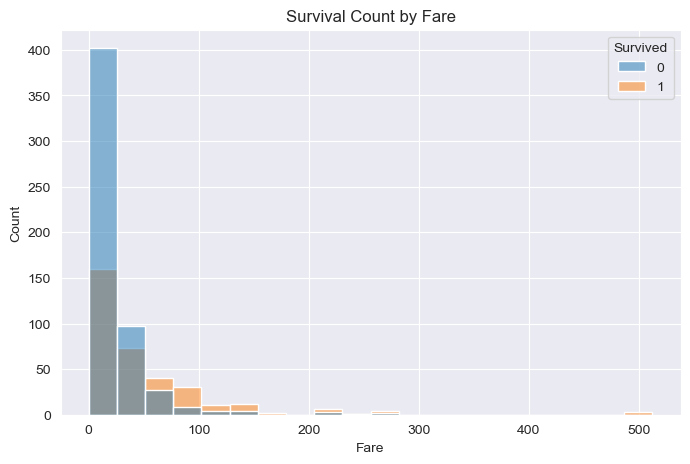

In [253]:
# plots for numerical features

# numerical_features = ['Age', 'Fare']
# 
# for feature in numerical_features:
#     plt.figure(figsize=(8, 5))
#     sns.histplot(data=train_df, x=feature, hue='Survived', bins=20)
#     plt.title('Survival Count by ' + feature)
#     plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(data=train_df, x='Fare', hue='Survived', bins=20)
plt.title('Survival Count by Fare')
plt.show()

   Pclass     Sex  Survived
0       1  female  0.968085
1       1    male  0.368852
2       2  female  0.921053
3       2    male  0.157407
4       3  female  0.500000
5       3    male  0.135447


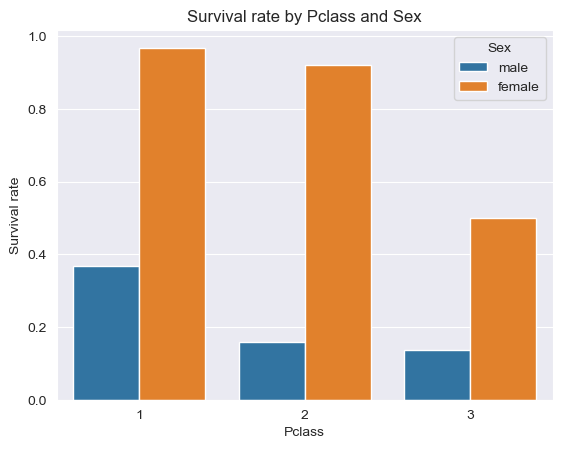

In [254]:
# Survival rate by pclass and sex
survival_rate_by_pclass_and_sex = train_df.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index()
print(survival_rate_by_pclass_and_sex)

sns.barplot(data=train_df, x='Pclass', y='Survived', hue='Sex', errorbar=None)
plt.title("Survival rate by Pclass and Sex")
plt.ylabel("Survival rate")
plt.show()

In [255]:
# drop Cabin and Ticket features on both datasets (duplicates/too many missing values)
# drop Name as it seems there is no apparent correlation with survival
# drop PassengerId on training dataset (because it's useless)

train_df = train_df.drop(['Ticket', 'Cabin', 'PassengerId', 'Name'], axis=1)
test_df = test_df.drop(['Ticket', 'Cabin', 'Name'], axis=1)

# print(train_df.shape, test_df.shape)

In [256]:
# impute age missing values

def impute_age(df, median_ages):
    df['Age'] = df.apply(
        lambda row: median_ages.loc[row['Pclass'], row['Sex']] if pd.isnull(row['Age']) else row['Age'], axis=1)
    return df


# calculate the median age for each combination of pclass and sex in the training set and test set
median_ages_train = train_df.groupby(['Pclass', 'Sex'])['Age'].median()
median_ages_test = test_df.groupby(['Pclass', 'Sex'])['Age'].median()

train_df = impute_age(train_df, median_ages_train)
test_df = impute_age(test_df, median_ages_test)

print(median_ages_train)
print("\n")
print(median_ages_test)

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64


Pclass  Sex   
1       female    41.0
        male      42.0
2       female    24.0
        male      28.0
3       female    22.0
        male      24.0
Name: Age, dtype: float64


In [257]:
# fill embark missing values from training dataset with most frequent value

most_freq = train_df['Embarked'].mode()[0]
train_df['Embarked'] = train_df['Embarked'].fillna(most_freq)

In [258]:
# fill Fare missing value on test dataset

fare_value = test_df['Fare'].mean()
fare_value = round(fare_value, 2)
test_df['Fare'].fillna(value=fare_value, inplace=True)

In [259]:
# DUMMY ENCODING sex column
# male : 1, female : 0

def process_sex_column(df):
    df = pd.get_dummies(data=df, columns=['Sex'], drop_first=True)
    df.rename(columns={'Sex_male': 'Sex'}, inplace=True)
    return df


train_df = process_sex_column(train_df)
test_df = process_sex_column(test_df)

# train_df.head(5)

In [260]:
# ONE HOT ENCONDING embarked column

train_df = pd.get_dummies(train_df, columns=['Embarked'])
test_df = pd.get_dummies(test_df, columns=['Embarked'])

# train_df.head(5)

In [261]:
# create new feature isAlone (with this we can drop SibSp and Parch features)

# if train_df['SibSp'] + train_df['Parch'] == 0 then isAlone = 1 else isAlone = 0
train_df['isAlone'] = np.where((train_df['SibSp'] + train_df['Parch']) == 0, 1, 0)
test_df['isAlone'] = np.where((test_df['SibSp'] + test_df['Parch']) == 0, 1, 0)

# survival rate for isAlone
print(train_df[['isAlone', 'Survived']].groupby(['isAlone']).mean().sort_values(by='Survived', ascending=False))

train_df.drop(['SibSp', 'Parch'], axis=1, inplace=True)
test_df.drop(['SibSp', 'Parch'], axis=1, inplace=True)

         Survived
isAlone          
0        0.505650
1        0.303538
